In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\housing.csv')

In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df_num = df.select_dtypes('number').copy()
df_cat = df.select_dtypes('object').copy()

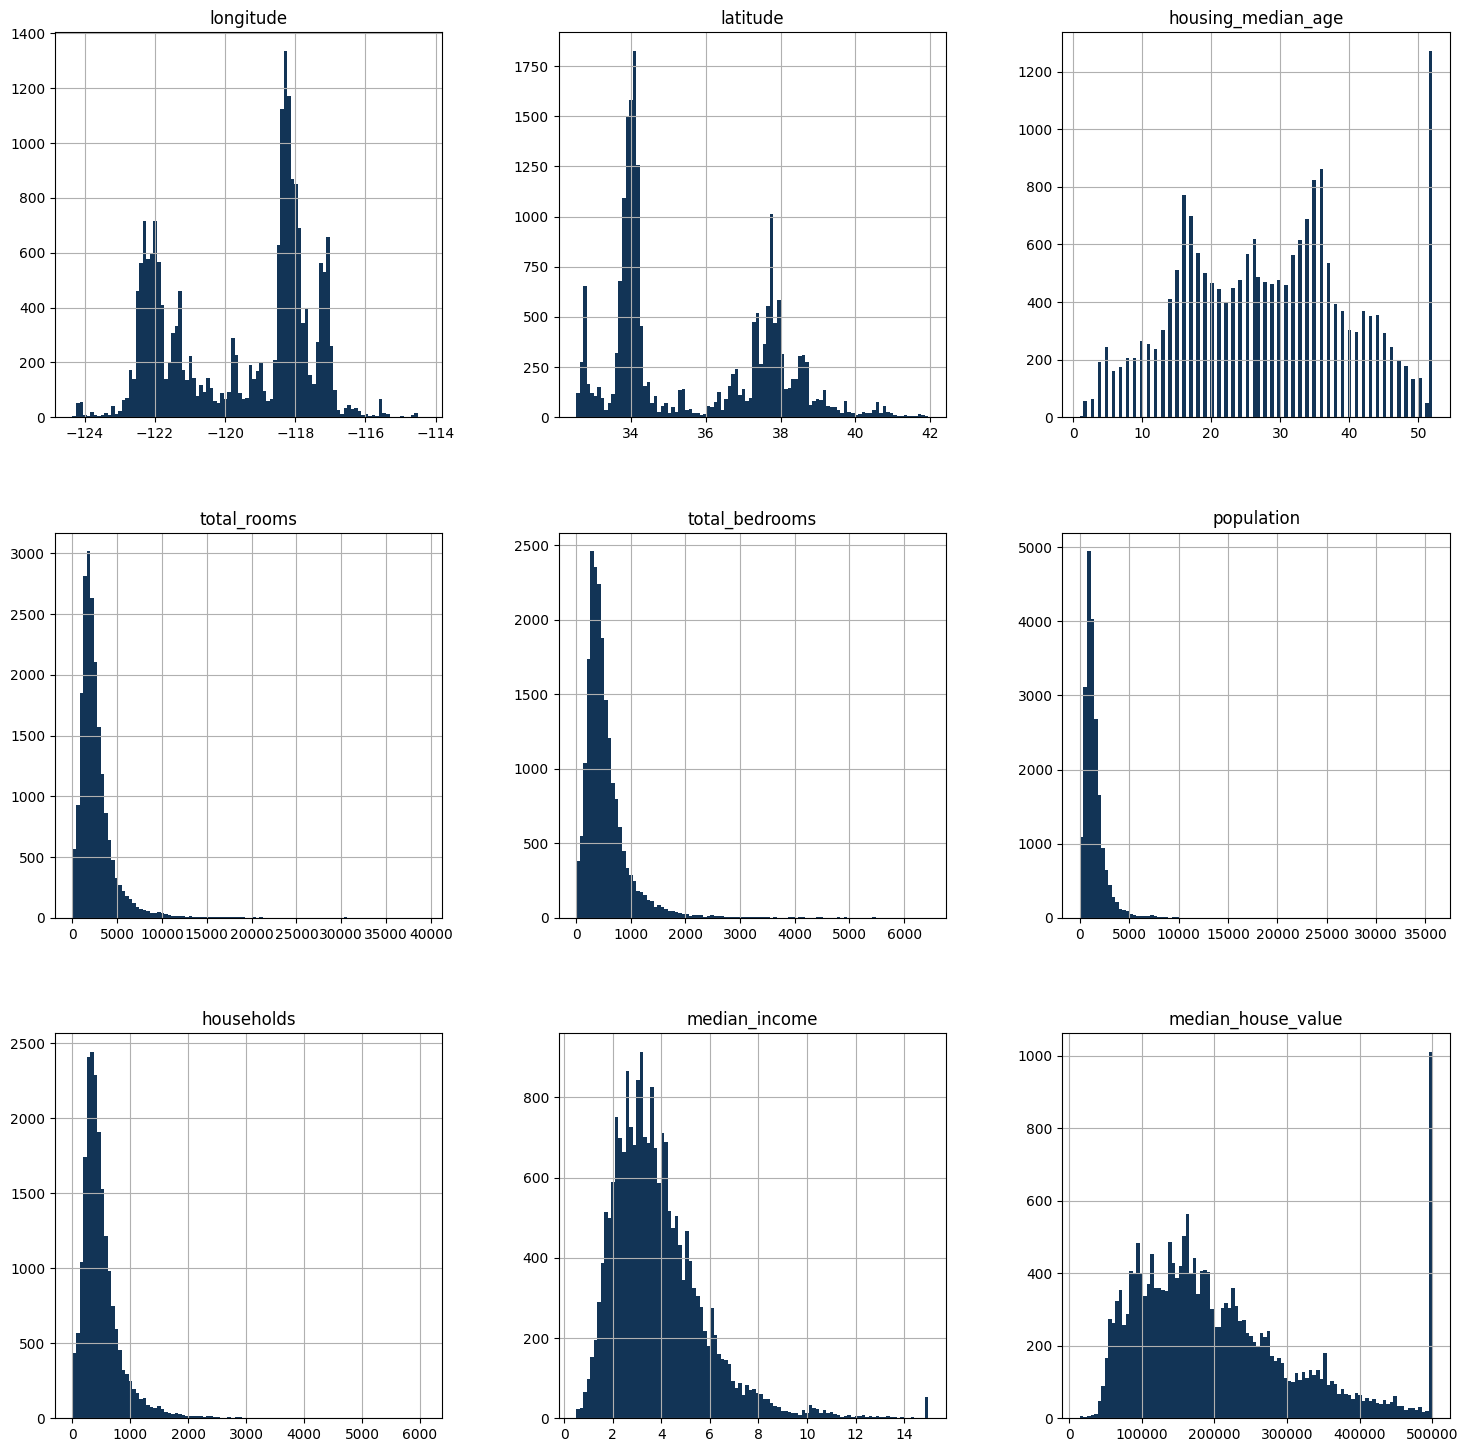

In [10]:
df_num.hist(figsize=(18, 18), bins=100, color='#123456')
plt.show()

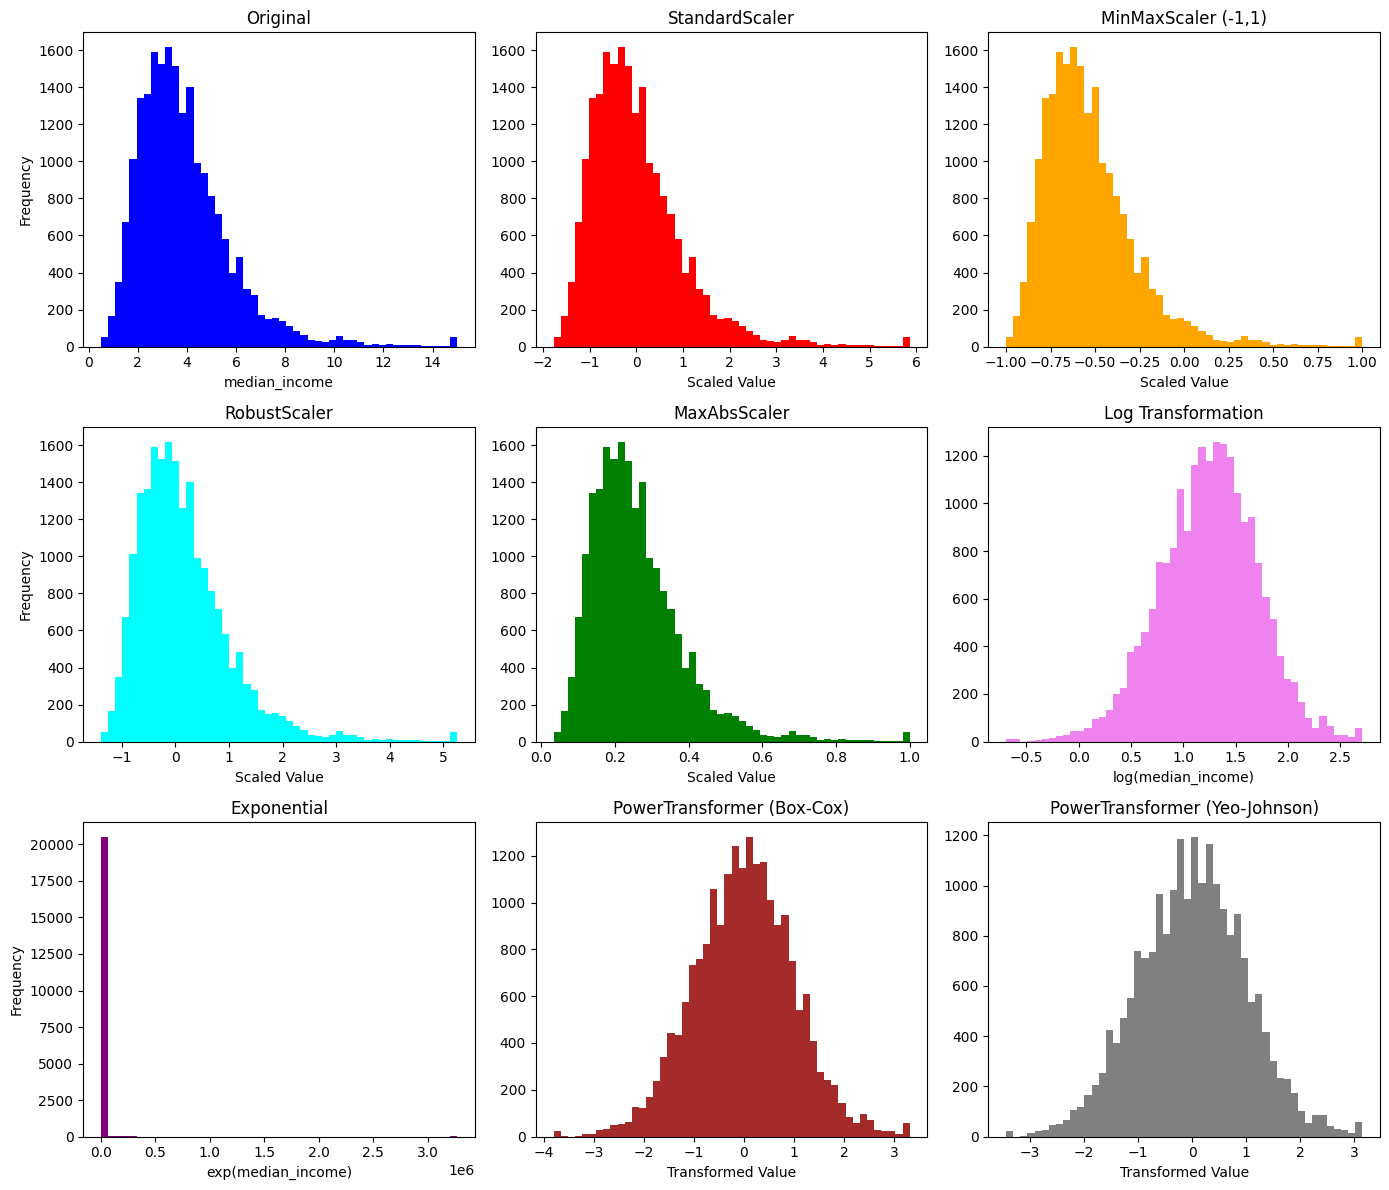

In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, PowerTransformer

ss = StandardScaler()
output_ss = ss.fit_transform(df[['median_income']])

mm = MinMaxScaler(feature_range=(-1, 1))
output_mm = mm.fit_transform(df[['median_income']])

rs = RobustScaler()
output_rs = rs.fit_transform(df[['median_income']])

ma = MaxAbsScaler()
output_ma = ma.fit_transform(df[['median_income']])

l = np.log(df[['median_income']])
r = np.exp(df[['median_income']])

ntB = PowerTransformer('box-cox')
ntY = PowerTransformer('yeo-johnson')
outputB = ntB.fit_transform(df[['median_income']])
outputY = ntY.fit_transform(df[['median_income']])

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(14,12))

# Original
axs[0,0].hist(df['median_income'], bins=50, color='blue')
axs[0,0].set_title("Original")
axs[0,0].set_xlabel("median_income")
axs[0,0].set_ylabel("Frequency")

# StandardScaler
axs[0,1].hist(output_ss, bins=50, color='red')
axs[0,1].set_title("StandardScaler")
axs[0,1].set_xlabel("Scaled Value")

# MinMaxScaler
axs[0,2].hist(output_mm, bins=50, color='orange')
axs[0,2].set_title("MinMaxScaler (-1,1)")
axs[0,2].set_xlabel("Scaled Value")

# RobustScaler
axs[1,0].hist(output_rs, bins=50, color='cyan')
axs[1,0].set_title("RobustScaler")
axs[1,0].set_xlabel("Scaled Value")
axs[1,0].set_ylabel("Frequency")

# MaxAbsScaler
axs[1,1].hist(output_ma, bins=50, color='green')
axs[1,1].set_title("MaxAbsScaler")
axs[1,1].set_xlabel("Scaled Value")

# Log
axs[1,2].hist(l, bins=50, color='violet')
axs[1,2].set_title("Log Transformation")
axs[1,2].set_xlabel("log(median_income)")

# Exp
axs[2,0].hist(r, bins=50, color='purple')
axs[2,0].set_title("Exponential")
axs[2,0].set_xlabel("exp(median_income)")
axs[2,0].set_ylabel("Frequency")

# Box-Cox
axs[2,1].hist(outputB, bins=50, color='brown')
axs[2,1].set_title("PowerTransformer (Box-Cox)")
axs[2,1].set_xlabel("Transformed Value")

# Yeo-Johnson
axs[2,2].hist(outputY, bins=50, color='gray')
axs[2,2].set_title("PowerTransformer (Yeo-Johnson)")
axs[2,2].set_xlabel("Transformed Value")

plt.tight_layout()
plt.show()